# Reconstruction of Tropical Cyclone HAROLD 2020 using GreenSurge

## Read simulation dataset

In [1]:
import xarray as xr

ds_GFD_info = xr.open_dataset(
    "outputs/GreenSurge_Tonga_info.nc",
    decode_times=False,
)
ds_GFD_info

<xarray.Dataset> Size: 230kB
Dimensions:                            (element_computation_index: 8657,
                                        triangle_forcing_nodes: 3,
                                        node_forcing_index: 15,
                                        element_forcing_index: 16,
                                        wind_direction_index: 8,
                                        time_forcing_index: 4,
                                        node_cumputation_index: 4553)
Coordinates:
  * element_computation_index          (element_computation_index) int32 35kB ...
  * node_forcing_index                 (node_forcing_index) int32 60B 0 1 ... 14
  * element_forcing_index              (element_forcing_index) int32 64B 0 .....
  * wind_direction_index               (wind_direction_index) int32 32B 0 ... 7
  * time_forcing_index                 (time_forcing_index) float64 32B 0.0 ....
  * node_cumputation_index             (node_cumputation_index) int32 18kB 0 ...
    node_computation_longitude         (node_cumputation_index) float64 36kB ...
    node_computation_latitude          (node_cumputation_index) float64 36kB ...
    triangle_nodes                     (triangle_forcing_nodes) int32 12B ...
Dimensions without coordinates: triangle_forcing_nodes
Data variables: (12/14)
    triangle_computation_connectivity  (element_computation_index, triangle_forcing_nodes) int32 104kB ...
    node_forcing_longitude             (node_forcing_index) float64 120B ...
    node_forcing_latitude              (node_forcing_index) float64 120B ...
    triangle_forcing_connectivity      (element_forcing_index, triangle_forcing_nodes) int32 192B ...
    wind_directions                    (wind_direction_index) int32 32B ...
    total_elements                     int32 4B ...
    ...                                 ...
    wind_speed                         int32 4B ...
    location_name                      object 8B ...
    eddy_viscosity                     int32 4B ...
    chezy_coefficient                  int32 4B ...
    reference_date                     object 8B ...
    forcing_time_step                  float64 8B ...
Attributes:
    title:        Hybrid Simulation Input Dataset
    description:  Structured dataset containing simulation parameters for hyb...
    created:      2025-10-19 21:42:17
    institution:  GeoOcean
    model:        GreenSurge
    source:       outputs/GreenSurge_Tonga_info.nc

In [2]:
figsize = (6, 5)
instant = [130, 160, 180]

## Read the data from the international-best-track-archive-for-climate-stewardship-ibtracs (v04r01 NOAA)

In [3]:
from bluemath_tk.config.paths import PATHS, update_paths

update_paths({"SHYTCWAVES_COEFS": "/courses-data/ibtracs_coef_pmin_wmax.nc"})
PATHS

{'SHYTCWAVES_COEFS': '/courses-data/ibtracs_coef_pmin_wmax.nc',
 'SHYTCWAVES_BULK': 'https://geoocean.sci.unican.es/thredds/dodsC/geoceanData/GEOOCEAN/SHyTCWaves_bulk/library_shytcwaves_bulk_params_int32.nc',
 'SHYTCWAVES_MDA': 'https://geoocean.sci.unican.es/thredds/dodsC/geoceanData/GEOOCEAN/SHyTCWaves_bulk/shytcwaves_mda.nc',
 'SHYTCWAVES_MDA_INDICES': 'https://geoocean.sci.unican.es/thredds/dodsC/geoceanData/GEOOCEAN/SHyTCWaves_bulk/shytcwaves_mda_indices.nc',
 'SHYTCWAVES_MDA_MASK_INDICES': 'https://geoocean.sci.unican.es/thredds/dodsC/geoceanData/GEOOCEAN/SHyTCWaves_bulk/mda_mask_indices.nc',
 'SHYTCWAVES_MDA_MASK_INDICES_LOWRES': 'https://geoocean.sci.unican.es/thredds/dodsC/geoceanData/GEOOCEAN/SHyTCWaves_bulk/mda_mask_indices_lowres.nc',
 'SHYTCWAVES_SPECTRA': '/lustre/geocean/DATA/GEOOCEAN/SHyTCWaves/'}

In [4]:
import numpy as np
from bluemath_tk.tcs.tracks import (
    historic_track_interpolation,
    historic_track_preprocessing,
)

p_tracks = "/courses-data/IBTrACS.ALL.v04r00.nc"
ibtracs = xr.open_dataset(p_tracks)
name = b"HAROLD"
TCname = "HAROLD2020"
year = 2020
centerID = "WMO"

storm = ibtracs.isel(
    storm=np.where(
        (ibtracs.name == name)  # TODO: necesita \ ?
        & (ibtracs.time[:, 0].dt.year.values == year)
    )[0]
).isel(storm=0)

df_TC_hist = historic_track_preprocessing(xds=storm, center=centerID)

# computational time step mandatory [60 min] for GS methodology:
dt_comp = ds_GFD_info.time_step_hours.values * 60

# generate interpolated storm track and mandatory data to apply vortex model
storm_track, time_input = historic_track_interpolation(df=df_TC_hist, dt_comp=dt_comp)
storm_track

* Data access can be requested to bluemath@unican.es
You can update any path or add new paths with the update_paths function, from bluemath_tk.config.paths.
Example: update_paths({'SHYTCWAVES_COEFS': '/new/path/to/data'})


,center,basin,dist2land,lon,lat,move,vf,vfx,vfy,pn,p0,vmax,rmw,vmaxfill,rmwfill
2020-04-01 00:00:00,WMO,SP,239.0,154.700001,-8.800000,303.988281,3.582242,2.970222,-2.002558,1013,1009.000000,15.000000,60.627998,False,True
2020-04-01 00:15:00,WMO,SP,239.0,154.712500,-8.808382,303.988281,3.582242,2.970222,-2.002558,1013,1009.000000,15.000000,60.648761,False,True
2020-04-01 00:30:00,WMO,SP,239.0,154.725000,-8.816764,303.988281,3.582242,2.970222,-2.002558,1013,1009.000000,15.000000,60.669524,False,True
2020-04-01 00:45:00,WMO,SP,239.0,154.737500,-8.825146,303.988281,3.582242,2.970222,-2.002558,1013,1009.000000,15.000000,60.690287,False,True
2020-04-01 01:00:00,WMO,SP,239.0,154.750001,-8.833527,303.988281,3.582242,2.970222,-2.002558,1013,1009.000000,15.000000,60.711050,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-04-09 22:45:00,WMO,SP,1712.0,197.966092,-28.856978,303.238037,34.033360,28.465512,-18.654334,1013,972.916667,62.083333,NaN,False,True
2020-04-09 23:00:00,WMO,SP,1712.0,198.103093,-28.932300,303.238037,34.033360,28.465512,-18.654334,1013,973.333333,61.666667,NaN,False,True
2020-04-09 23:15:00,WMO,SP,1712.0,198.240291,-29.007482,303.238037,34.033360,28.465512,-18.654334,1013,973.750000,61.250000,NaN,False,True
2020-04-09 23:30:00,WMO,SP,1712.0,198.377688,-29.082522,303.238037,34.033360,28.465512,-18.654334,1013,974.166667,60.833333,NaN,False,True


## Select storm track for the period of interest

In [5]:
# preprocess selected historic TC: obtain strom variables
# Storm fraction selection based on temporal coverture (period when the cyclone passes close to Tonga)

# HAROLD2020
tini = np.datetime64("2020-04-07T00:00")
tend = np.datetime64("2020-04-09T17:00")

storm_track_sel = storm_track[(storm_track.index >= tini) & (storm_track.index <= tend)]

## Gerenate a regular grid for the vortex model and apply the vortex model to the storm track

In [6]:
from bluemath_tk.additive.greensurge import get_regular_grid
from bluemath_tk.tcs.vortex import vortex_model_grid

lon_grid, lat_grid = get_regular_grid(
    node_computation_longitude=ds_GFD_info.node_computation_longitude.values,
    node_computation_latitude=ds_GFD_info.node_computation_latitude.values,
    node_computation_elements=ds_GFD_info.triangle_computation_connectivity.values,
    factor=10,
)

xds_vortex_GS = vortex_model_grid(
    storm_track=storm_track_sel,
    cg_lon=lon_grid,
    cg_lat=lat_grid,
    coords_mode="SPHERICAL",
)

xds_vortex_GS.to_netcdf(
    f"outputs/GreenSurge_vortex_{TCname}.nc",
)

## Means realisation of the vortex model on the forcing grid

<div style="border: 1px solid #cce5ff; background-color: #e9f7fe; padding: 15px; border-radius: 6px; font-family: sans-serif;">
  <strong>🔹 Vortex Wind Fields</strong><br><br>

  The second stage for any TC event study includes: 
  <ul>
    <li>Partition of original TC-induced wind fields (regardless of their origin: from parameterizations using Holland vortex model or from forecasting systems) taking into account spatial (i.e. cells) and temporal (i.e. length of sustained winds) resolutions defined in stage 1. </li>
    <li>Search for analogues of the above wind forcing partition for each cell and time step in the corresponding forcings of the GFD pre-computed in stage 1. At this point, it is worth mentioning that, since a unit wind is used, the search for analogues is based on wind directions only. </li>
    <li>Re-scaling of the corresponding wind setup according to the realistic wind magnitude taking into account the quadratic expression of the wind shear stress used at the free surface boundary condition for the momentum equations. </li>
    <li>Summation of the re-scaled wind setup corresponding to the Green’s Fuctions selected by directional analogy for each time step </li>
  </ul>
</div>

In [7]:
from bluemath_tk.additive.greensurge import GS_wind_partition_tri

xds_vortex_interp = GS_wind_partition_tri(
    ds_GFD_info=ds_GFD_info, xds_vortex=xds_vortex_GS
)

## Exemples of instant of wind partitioning

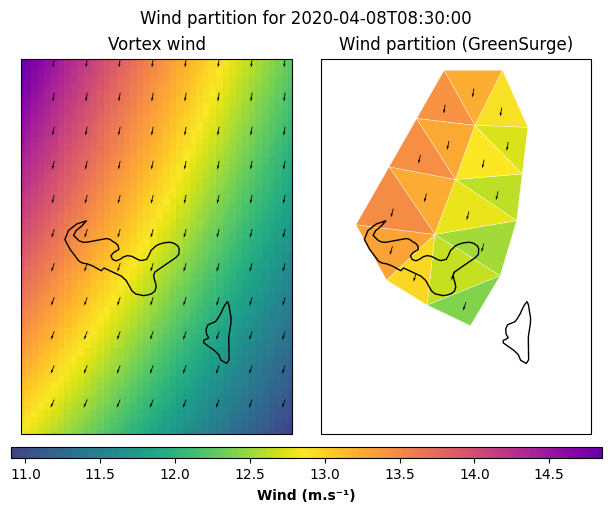

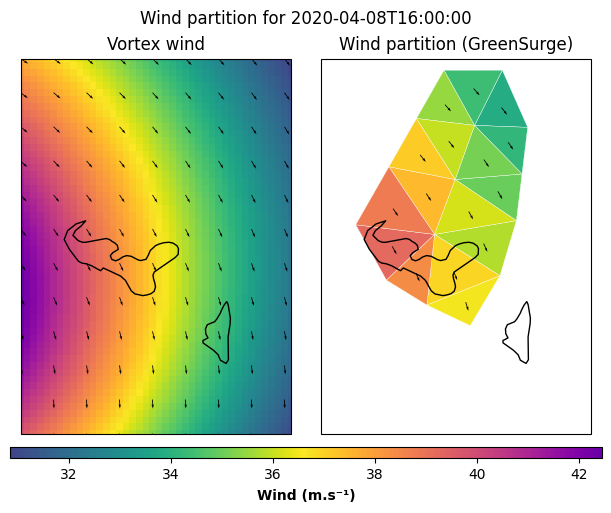

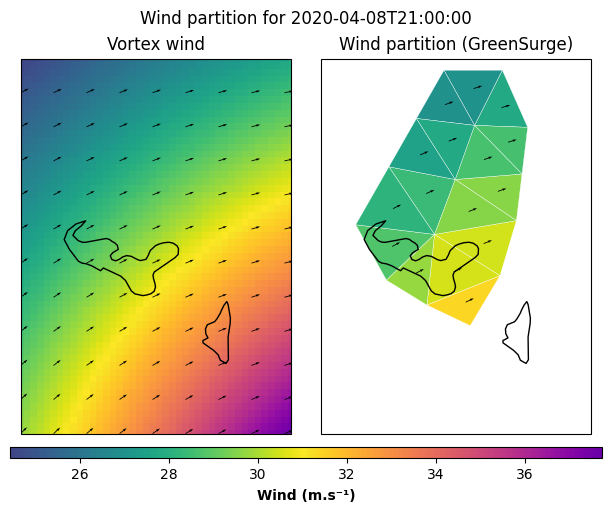

In [8]:
from bluemath_tk.additive.greensurge import plot_GS_input_wind_partition

for i in instant:
    plot_GS_input_wind_partition(
        xds_vortex_GS=xds_vortex_GS,
        xds_vortex_interp=xds_vortex_interp,
        ds_GFD_info=ds_GFD_info,
        i_time=i,
        figsize=figsize,
    )

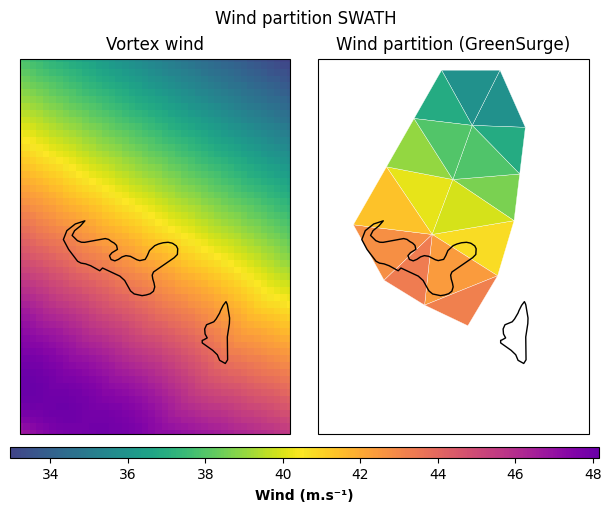

In [9]:
plot_GS_input_wind_partition(
    xds_vortex_GS=xds_vortex_GS,
    xds_vortex_interp=xds_vortex_interp,
    ds_GFD_info=ds_GFD_info,
    SWATH=True,
    figsize=figsize,
)

## Loading the reconstruction library for this specific event

In [10]:
from bluemath_tk.additive.greensurge import load_GS_database

p_GFD_libdir = "TONGA_CASES/GreenSurge_Postprocess"

GFD = load_GS_database(
    xds_vortex_interp=xds_vortex_interp,
    ds_GFD_info=ds_GFD_info,
    p_GFD_libdir=p_GFD_libdir,
)
GFD

<xarray.Dataset> Size: 139MB
Dimensions:        (direction: 5, forcing_cell: 16, time: 25,
                    mesh2d_nFaces: 8657)
Coordinates:
  * direction      (direction) int64 40B 0 1 5 6 7
  * forcing_cell   (forcing_cell) int64 128B 0 1 2 3 4 5 6 ... 10 11 12 13 14 15
  * time           (time) datetime64[ns] 200B 2022-01-01 ... 2022-01-01T06:00:00
    mesh2d_face_x  (mesh2d_nFaces) float64 69kB dask.array<chunksize=(8657,), meta=np.ndarray>
    mesh2d_face_y  (mesh2d_nFaces) float64 69kB dask.array<chunksize=(8657,), meta=np.ndarray>
Dimensions without coordinates: mesh2d_nFaces
Data variables:
    mesh2d_s1      (direction, forcing_cell, time, mesh2d_nFaces) float64 139MB dask.array<chunksize=(1, 16, 25, 8657), meta=np.ndarray>
Attributes: (12/18)
    institution:               Deltares
    references:                https://www.deltares.nl
    source:                    D-Flow FM 1.2.184.Unknown. Model:
    history:                   Created on 2025-10-19T21:42:27-0000, D-Flow FM
    date_created:              2025-10-19T21:42:27-0000
    date_modified:             2025-10-19T21:42:27-0000
    ...                        ...
    geospatial_lon_max:        -174.744455622
    geospatial_lon_units:      degrees_east
    time_coverage_start:       2022-01-01T00:00:00+00:00
    time_coverage_end:         2022-01-01T06:00:00+00:00
    time_coverage_duration:    P0000-00-00T06:00:00
    time_coverage_resolution:  P0000-00-00T00:15:00

## Run: Searching for analogues, re-scaling and applying wind-drag coefficient

In [11]:
from bluemath_tk.additive.greensurge import (
    GS_windsetup_reconstruction_with_postprocess,
)

xds_GS_wind = GS_windsetup_reconstruction_with_postprocess(
    greensurge_dataset=GFD,
    ds_gfd_metadata=ds_GFD_info,
    wind_direction_input=xds_vortex_interp,
    velocity_thresholds=np.array([0, 100, 100]),
    drag_coefficients=np.array([0.00063, 0.00723, 0.00723]),
)

xds_GS_wind.to_netcdf(f"outputs/GreenSurge_wind_setup_{TCname}.nc")

Processing time steps: 100%|██████████| 260/260 [01:11<00:00,  3.62it/s]
